In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [27]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
url

'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

In [28]:
column_names = ["mpg","cylinders","displacement","horsepower","weight","acceleration","model_year","origin","car_name"]
column_names

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model_year',
 'origin',
 'car_name']

In [29]:
df = pd.read_csv(
    url,
    names=column_names,
    sep=r"\s+", # raw file is separated by whitespace not commas
    na_values="?",  # Treat '?' as NaN
    comment='\t',  # Ignore comments starting with tab
    )
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [30]:
df.shape

(398, 9)

In [31]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger
397,31.0,4,119.0,82.0,2720.0,19.4,82,1,chevy s-10


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [33]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [34]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [35]:
print("Rows before dropping missing values:", df.shape[0])
df = df.dropna().reset_index(drop=True)
print("Rows after dropping missing values:", df.shape[0])

Rows before dropping missing values: 398
Rows after dropping missing values: 392


In [36]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
388,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
389,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
390,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


In [37]:
car_names = df['car_name']

In [38]:
df = df.drop(columns=['car_name'])  # Drop the car_name column as it's not needed for modeling

In [39]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [40]:
df['origin'].unique()

array([1, 3, 2])

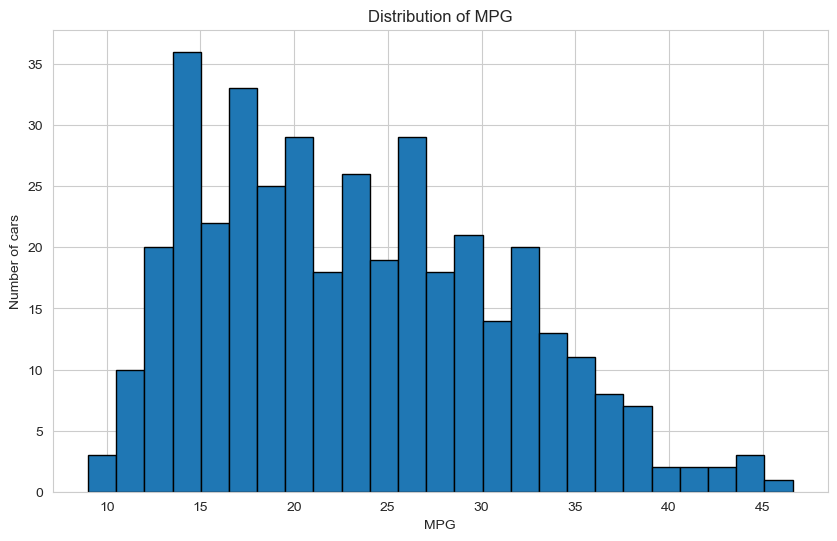

In [41]:
plt.figure()
plt.hist(df['mpg'], bins=25, edgecolor='black')
plt.xlabel('MPG')
plt.ylabel('Number of cars')
plt.title('Distribution of MPG')
plt.show()

In [42]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin'],
      dtype='object')

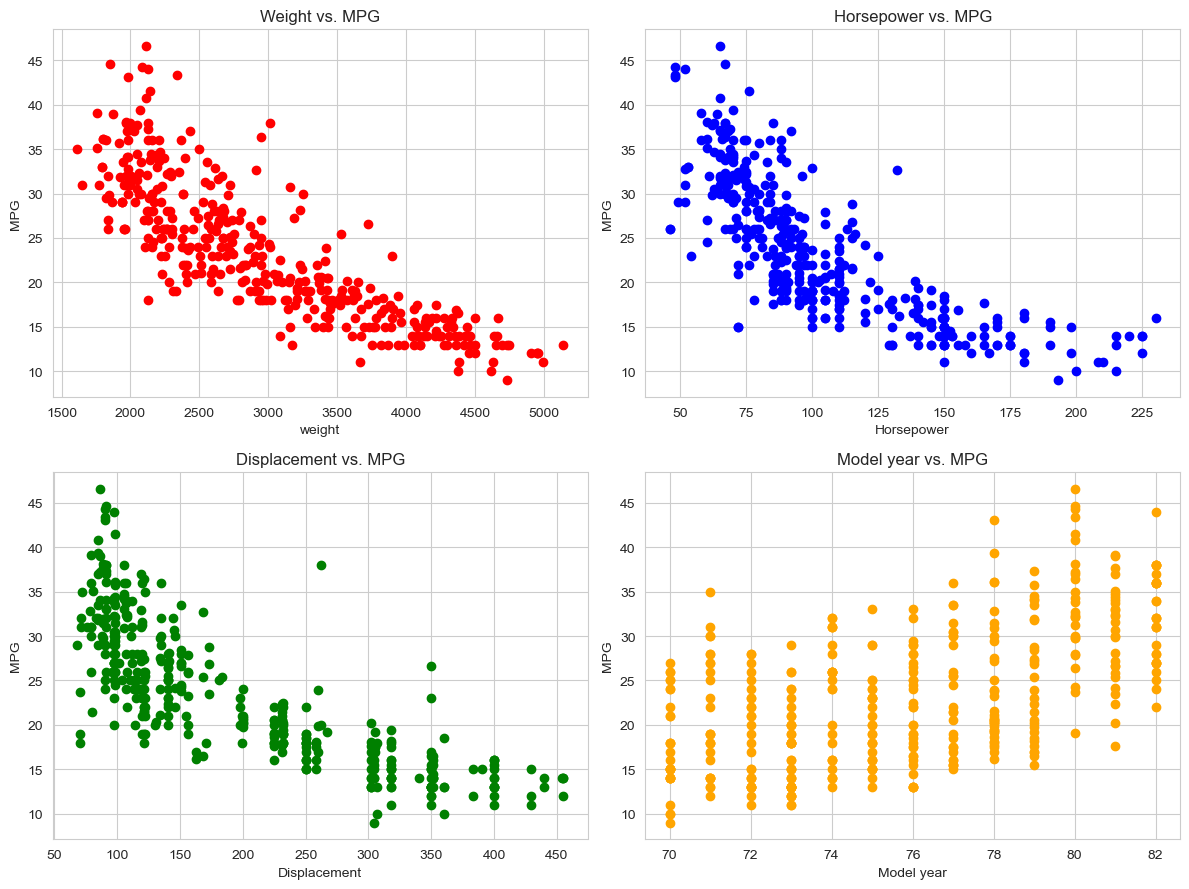

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(df['weight'], df['mpg'], color='red')
axes[0, 0].set_xlabel('weight')
axes[0, 0].set_ylabel('MPG')
axes[0, 0].set_title('Weight vs. MPG')

axes[0, 1].scatter(df['horsepower'], df['mpg'], color='blue')
axes[0, 1].set_xlabel('Horsepower')
axes[0, 1].set_ylabel('MPG')
axes[0, 1].set_title('Horsepower vs. MPG')

axes[1, 0].scatter(df['displacement'], df['mpg'], color='green')
axes[1, 0].set_xlabel('Displacement')
axes[1, 0].set_ylabel('MPG')
axes[1, 0].set_title('Displacement vs. MPG')

axes[1, 1].scatter(df['model_year'], df['mpg'], color='orange')
axes[1, 1].set_xlabel('Model year')
axes[1, 1].set_ylabel('MPG')
axes[1, 1].set_title('Model year vs. MPG')

plt.tight_layout()
plt.show()


C:\Users\Acer\AppData\Local\Temp\ipykernel_11012\1729509651.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['origin'], y=df['mpg'], palette='Set2')


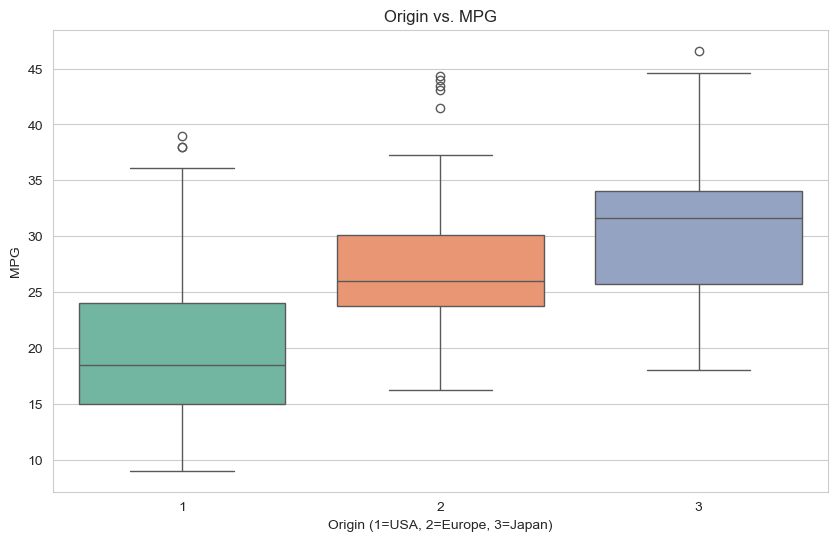

In [47]:
plt.figure()
sns.boxplot(x=df['origin'], y=df['mpg'], palette='Set2')
plt.xlabel('Origin (1=USA, 2=Europe, 3=Japan)')
plt.ylabel('MPG')
plt.title('Origin vs. MPG')
plt.show()

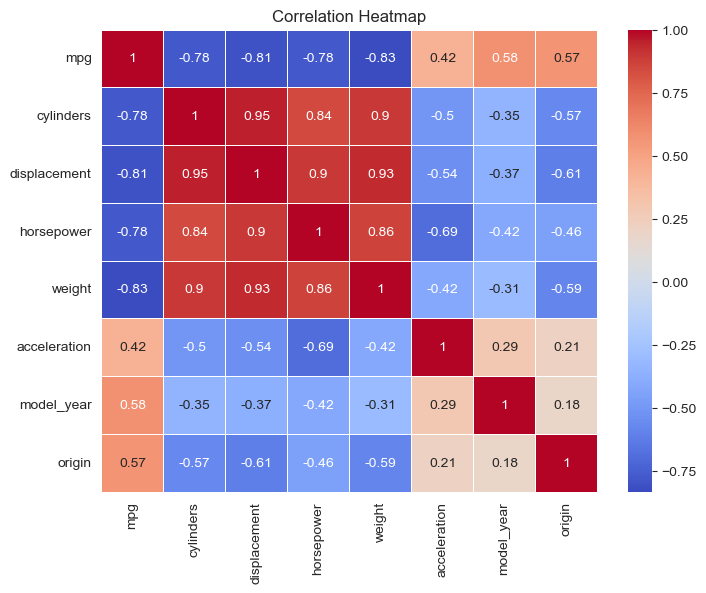

In [48]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [49]:
X = df.drop(columns=['mpg'])
y = df['mpg']

In [50]:
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (392, 7)
y shape: (392,)


In [51]:
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,8,307.0,130.0,3504.0,12.0,70,1
1,8,350.0,165.0,3693.0,11.5,70,1
2,8,318.0,150.0,3436.0,11.0,70,1
3,8,304.0,150.0,3433.0,12.0,70,1
4,8,302.0,140.0,3449.0,10.5,70,1


In [52]:
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [54]:
print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

Training rows: 313
Test rows: 79


In [55]:
X_train['origin']

258    1
182    1
172    1
63     1
340    1
      ..
71     1
106    1
270    1
348    1
102    1
Name: origin, Length: 313, dtype: int64

In [56]:
X_train = pd.get_dummies(X_train, columns=['origin'], prefix='origin')
X_test = pd.get_dummies(X_test, columns=['origin'], prefix='origin')

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [57]:
X_test.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3
78,4.0,96.0,69.0,2189.0,18.0,72.0,0.0,1.0,0.0
274,4.0,121.0,115.0,2795.0,15.7,78.0,0.0,1.0,0.0
246,4.0,91.0,60.0,1800.0,16.4,78.0,0.0,0.0,1.0
55,4.0,91.0,70.0,1955.0,20.5,71.0,1.0,0.0,0.0
387,4.0,140.0,86.0,2790.0,15.6,82.0,1.0,0.0,0.0


In [59]:
X_train.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3
258,6.0,225.0,110.0,3620.0,18.700001,78.0,1.0,0.0,0.0
182,4.0,140.0,92.0,2572.0,14.900000,76.0,1.0,0.0,0.0
172,6.0,171.0,97.0,2984.0,14.500000,75.0,1.0,0.0,0.0
63,8.0,318.0,150.0,4135.0,13.500000,72.0,1.0,0.0,0.0
340,4.0,86.0,64.0,1875.0,16.400000,81.0,1.0,0.0,0.0


In [60]:
normalizer = layers.Normalization(axis=-1)
normalizer.adapt(np.array(X_train))

print('Learned per feature mean (first 5)', normalizer.mean.numpy().flatten()[:5])
print('Learned per feature variance (first 5)', normalizer.variance.numpy().flatten()[:5])

Learned per feature mean (first 5) [   5.482428  195.51758   104.594246 2986.1245     15.544088]
Learned per feature variance (first 5) [2.8822794e+00 1.0733099e+04 1.4609568e+03 7.0524594e+05 7.9149890e+00]


In [61]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
y_pred_lr = lin_reg.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear regression - MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}, RMSE: {rmse_lr:.2f}, R2: {r2_lr:.2f}")

Linear regression - MAE: 2.46, MSE: 10.60, RMSE: 3.26, R2: 0.79


In [63]:
n_features = X_train.shape[1]

print("Number of input features:", n_features)

Number of input features: 9


In [64]:
dense1_model = keras.Sequential([
    normalizer,
    layers.Dense(1)
])

dense1_model.build(input_shape=(None, n_features))
dense1_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (120.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 19 (80.00 B)

In [65]:
weights, bias = dense1_model.layers[-1].get_weights()
print("Initial weights shape:", weights.shape)
print("Initial weights:", weights.flatten())
print("Inital bias:", bias)


Initial weights shape: (9, 1)
Initial weights: [-0.19004405 -0.4705936  -0.24365485 -0.7507285  -0.00190848  0.47068274
  0.00905567 -0.27862814  0.23633862]
Inital bias: [0.]


In [66]:
initial_preds = dense1_model.predict(X_train[:5], verbose=0).flatten()
actual_vals = y_train.values[:5]

print("Predicted MPG (untrained model):", np.round(initial_preds, 2))
print("Actual MPG:", actual_vals)

initial_mse = np.mean((initial_preds - actual_vals) ** 2)
print("Initial MSE:", initial_mse)

Predicted MPG (untrained model): [-0.56  0.85 -0.05 -2.69  2.54]
Actual MPG: [18.6 25.  18.  15.  39. ]
Initial MSE: 583.5924986954572


In [69]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [70]:
ann_model = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

ann_model.build(input_shape=(None, n_features))
ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,772 (10.83 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 19 (80.00 B)